# Fit your first model

Fit a Gaussian regression with {class}`LieselOptim <liesel.optim.LieselOptim>`, then add validation data and
minibatches. You should already know how to build a Liesel model.

In [1]:
import logging

import jax.numpy as jnp
import numpy as np
import pandas as pd
import optax
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

logging.getLogger("liesel").setLevel(logging.WARNING)

## Build a small model

We simulate a line with intercept 0.7, slope −1.4, and noise standard deviation
0.6. We fit the coefficients and `log_sigma`; taking its exponential keeps the
standard deviation positive.

In [2]:
rng = np.random.default_rng(202405)
x = rng.uniform(-2.0, 2.0, size=240)
X_values = np.column_stack([np.ones_like(x), x])
y_values = X_values @ np.array([0.7, -1.4]) + rng.normal(scale=0.6, size=x.size)

beta = lsl.Var.new_param(
    jnp.zeros(2), lsl.Dist(tfd.Normal, loc=0.0, scale=5.0), name="beta"
)
log_sigma = lsl.Var.new_param(
    jnp.array(0.0), lsl.Dist(tfd.Normal, loc=0.0, scale=1.0), name="log_sigma"
)
sigma = lsl.Var.new_calc(jnp.exp, log_sigma, name="sigma")
X = lsl.Var.new_obs(jnp.asarray(X_values), name="X")
mu = lsl.Var.new_calc(lambda X, beta: X @ beta, X, beta, name="mu")
y = lsl.Var.new_obs(
    jnp.asarray(y_values), lsl.Dist(tfd.Normal, loc=mu, scale=sigma), name="y"
)
model = lsl.Model(y)

Plot the model to see how its variables depend on one another:

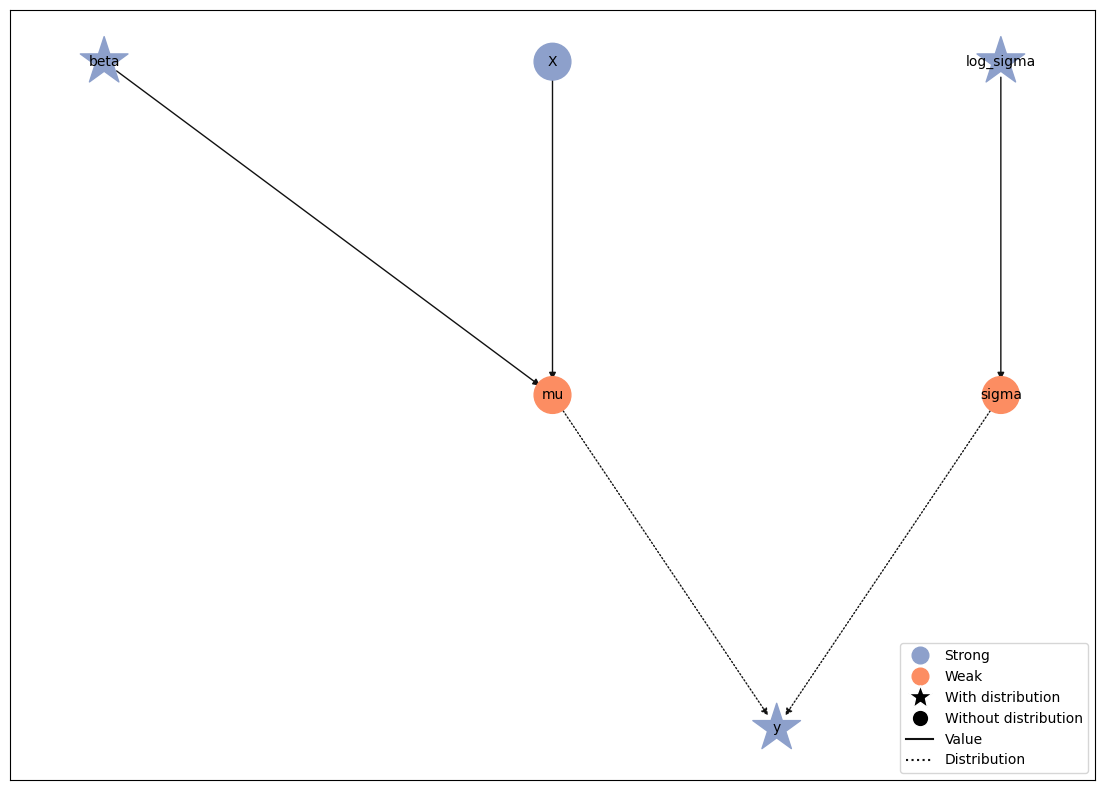

In [3]:
model.plot()

## Fit using all data

L-BFGS works well for this small, deterministic model. It needs full-data
batches. `train_full_data` checks the full training loss after each epoch.

In [4]:
result = opt.LieselOptim(
    model,
    optimizers="lbfgs",
    loss_monitor="train_full_data",
    stopper=opt.Stopper(epochs=40, patience=8, rtol=1e-6),
    show_progress=False,
    seed=1,
).fit()
position = result.position_min_monitor

In [5]:
pd.DataFrame(
    {"estimate": np.r_[position["beta"], jnp.exp(position["log_sigma"])]},
    index=["intercept", "slope", "sigma"],
).round(3)

,estimate
intercept,0.699
slope,-1.372
sigma,0.579


The fitted intercept (about 0.70), slope (−1.37), and noise standard
deviation (0.58) are close to the simulated values 0.7, −1.4, and 0.6.
Finite data and the priors mean we should not expect an exact match.

{attr}`position_min_monitor <liesel.optim.OptimResult.position_min_monitor>` gives the saved parameters with the lowest monitoring
loss. Use {attr}`position_final <liesel.optim.OptimResult.position_final>` for the last update instead. Fitting leaves the
original model unchanged.

## Hold out data

Split `X` and `y` together so each response keeps its matching row. Validation
chooses when to stop. The test data stay unused until the final check.

In [6]:
split = opt.PositionSplit.from_model(
    model,
    position_keys=["X", "y"],
    validate_axis_share=0.2,
    test_axis_share=0.1,
    seed=11,
)

## Fit with minibatches

Create batches from the training split and switch to Adam. Each update uses
32 training rows; the loss automatically accounts for the smaller batch. An epoch runs all full batches.
The stopper allows 250 epochs and checks improvement over the last 30.

In [7]:
batches = opt.Batches.from_split(split, batch_size=32)
result = opt.LieselOptim(
    model,
    split=split,
    batches=batches,
    optimizers=optax.adam(0.01),
    loss_monitor="validation",
    stopper=opt.Stopper(epochs=250, patience=30, rtol=1e-4),
    show_progress=False,
    seed=12,
).fit()
position = result.position_min_monitor

In [8]:
pd.DataFrame(
    {"estimate": np.r_[position["beta"], jnp.exp(position["log_sigma"])]},
    index=["intercept", "slope", "sigma"],
).round(3)

,estimate
intercept,0.691
slope,-1.361
sigma,0.598


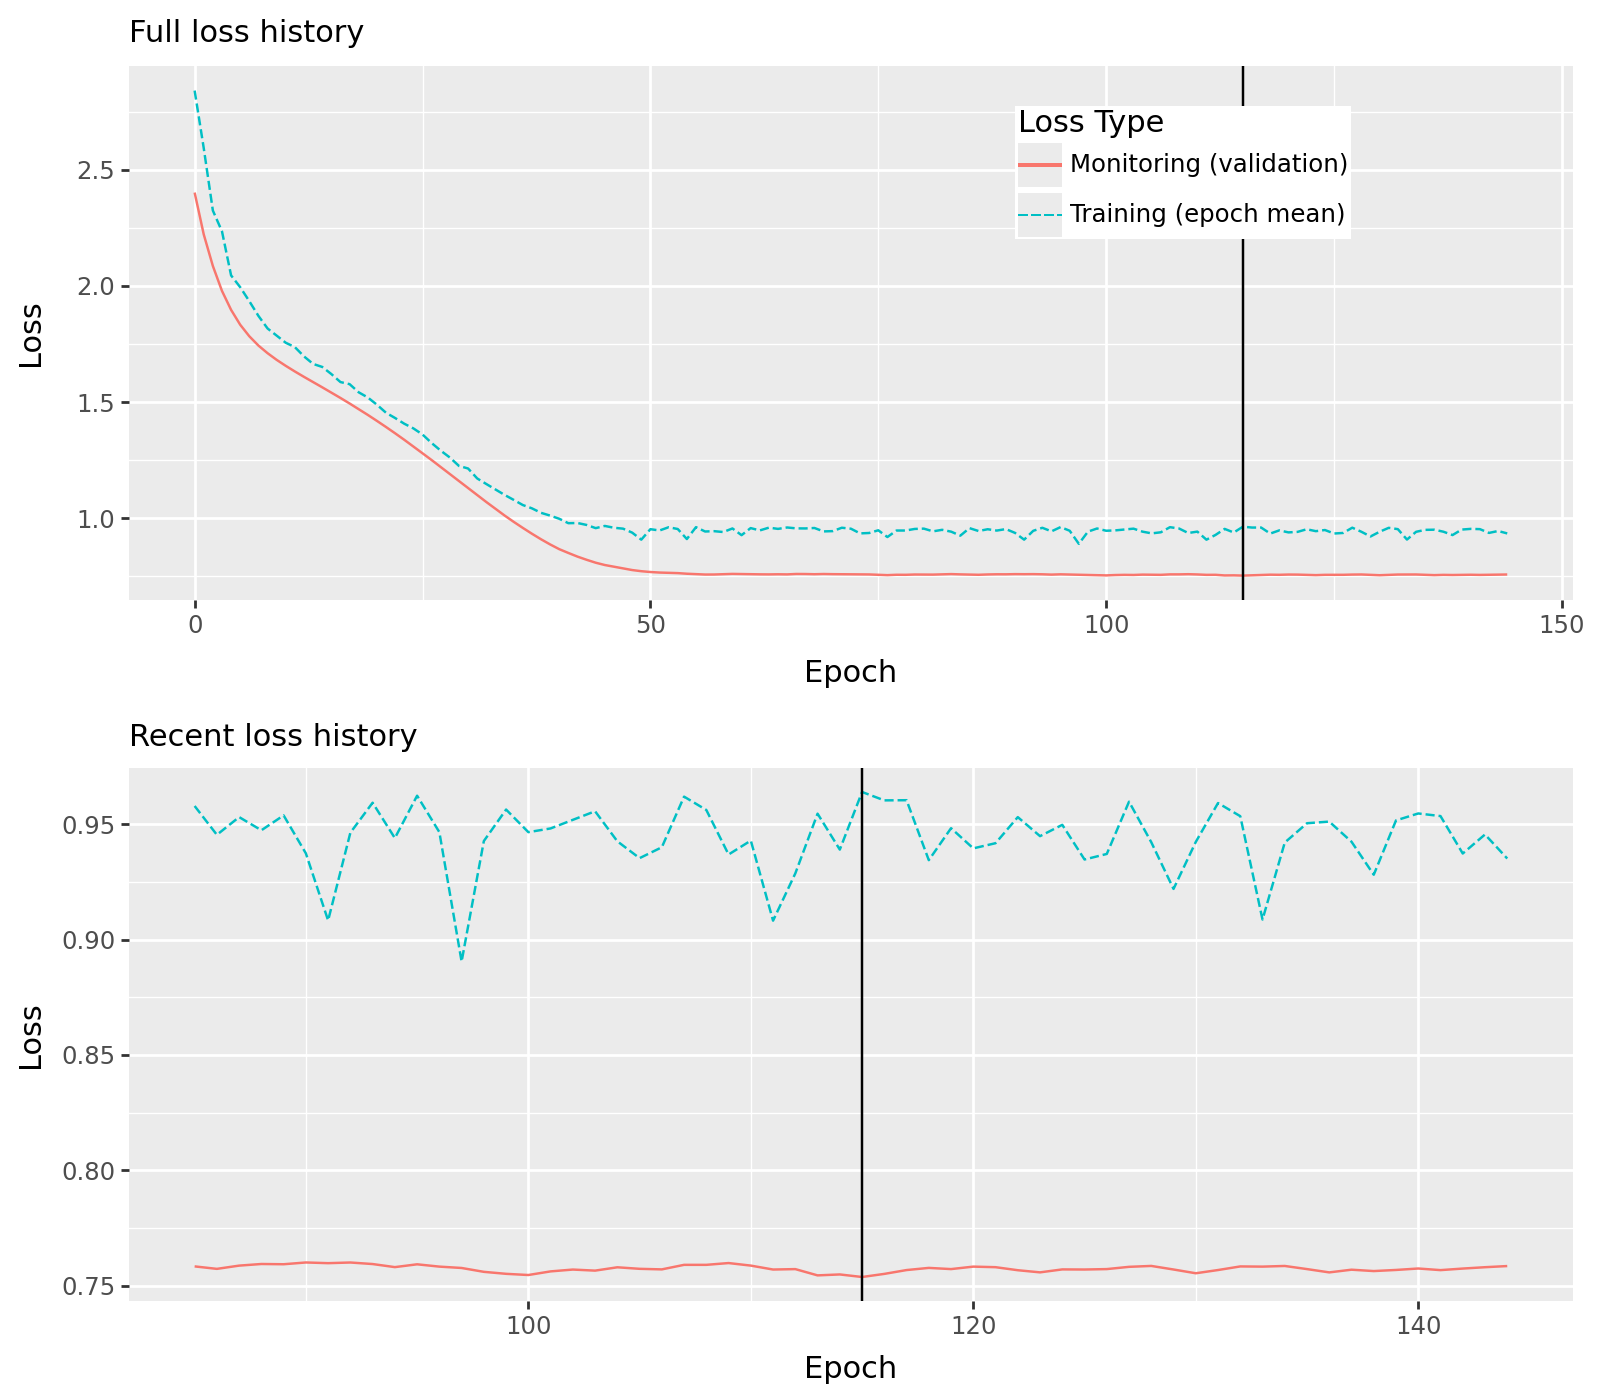

In [9]:
result.plot_loss_overview()

The minibatch fit also recovers the simulated values: the intercept is about
0.69, the slope −1.36, and the noise standard deviation 0.60. Both loss curves
fall at first and level off after roughly 50 epochs. The recent-history panel
shows small fluctuations; the vertical line marks the lowest validation loss.
This suggests little further validation improvement, not proof of an exact
optimum.

The training curve averages losses seen during each epoch and includes priors.
The validation curve evaluates likelihood on its full held-out split at the
end of the epoch. Because their data and objectives differ, the curves need
not coincide. See {doc}`monitoring and early stopping <../../optimizer-monitoring>`
for other choices.

## Check the held-out fit

This is the mean negative test log likelihood; smaller is better. It evaluates
the Adam fit, which used only the training split. The earlier L-BFGS example
used all rows.

In [10]:
test_state = model.update_state(position | split.test, model.state)
test_loss = (
    -split.scaled_log_lik(model, test_state, part="test") / split.train_sample_size
)

In [11]:
float(test_loss)

0.8761328458786011

To use the fitted parameters in the original model, assign its updated state:

In [12]:
model.state = model.update_state(position, model.state)

Next: {doc}`fit a model with two data groups <10-liesel-optim-advanced>`, or
{doc}`choose optimizers and learning rates <../../optimizer-customization>`.